#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Comparison of top predicted metabolites per model

In [3]:
path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Tissue_res'

r2_ridge = pd.read_csv(f'{path}/r2_ridge.csv')
r2_lasso = pd.read_csv(f'{path}/r2_lasso.csv')
r2_elastic = pd.read_csv(f'{path}/r2_elastic.csv')
r2_rf = pd.read_csv(f'{path}/r2_rf.csv')
r2_lgbm = pd.read_csv(f'{path}/r2_lgbm.csv')
r2_xgb = pd.read_csv(f'{path}/r2_xgb.csv')
r2_mlp = pd.read_csv(f'{path}/r2_mlp.csv',)
r2_ensemble = pd.read_csv(f'{path}//r2_ensemble.csv')

spearman_ridge = pd.read_csv(f'{path}/spearman_ridge.csv')
spearman_lasso = pd.read_csv(f'{path}/spearman_lasso.csv')
spearman_elastic = pd.read_csv(f'{path}/spearman_elastic.csv')
spearman_rf = pd.read_csv(f'{path}/spearman_rf.csv')
spearman_lgbm = pd.read_csv(f'{path}/spearman_lgbm.csv')
spearman_xgb = pd.read_csv(f'{path}/spearman_xgb.csv')
spearman_mlp = pd.read_csv(f'{path}/spearman_mlp.csv')
spearman_ensemble = pd.read_csv(f'{path}/spearman_ensemble.csv')

In [4]:
#Comparing r2

def get_list_high_r2_metabolites(r2_df, score_threshold):
  r2_df_top = r2_df[r2_df['R2 Score'] > score_threshold]
  top_metabolites = r2_df_top['Metabolite'].to_list()
  return top_metabolites

In [5]:
r2_threshold = 0.5

ridge_metabolites = get_list_high_r2_metabolites(r2_df = r2_ridge, score_threshold = r2_threshold)
lasso_metabolites = get_list_high_r2_metabolites(r2_df = r2_lasso, score_threshold = r2_threshold)
elastic_metabolites = get_list_high_r2_metabolites(r2_df = r2_elastic, score_threshold = r2_threshold)
rf_metabolites = get_list_high_r2_metabolites(r2_df = r2_rf, score_threshold = r2_threshold)
xgb_metabolites = get_list_high_r2_metabolites(r2_df = r2_xgb, score_threshold = r2_threshold)
lgbm_metabolites = get_list_high_r2_metabolites(r2_df = r2_lgbm, score_threshold = r2_threshold)
mlp_metabolites = get_list_high_r2_metabolites(r2_df = r2_mlp, score_threshold = r2_threshold)
ensemble_metabolites = get_list_high_r2_metabolites(r2_df = r2_ensemble, score_threshold = r2_threshold)

In [6]:
def find_common_elements(lists):
  common_elements = set(lists[0])
  for i in range(1, len(lists)):
    common_elements = common_elements.intersection(lists[i])
  return common_elements

common_r2_high = find_common_elements([ridge_metabolites, lasso_metabolites, elastic_metabolites, rf_metabolites, xgb_metabolites, lgbm_metabolites, mlp_metabolites, ensemble_metabolites])
len(common_r2_high)

126

In [7]:
with open(f'{path}/common_r2_high.txt', 'w') as file:
    for metabolite in common_r2_high:
        file.write(f"{metabolite}\n")

In [8]:
#Comparing spearman's

def get_list_high_spearman_metabolites(spearman_df, score_threshold):
  spearman_df_top = spearman_df[spearman_df['Spearman Coefficient'] > score_threshold]
  top_metabolites = spearman_df_top['Metabolite'].to_list()
  return top_metabolites

In [9]:
spearmans_threshold = 0.5

ridge_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_ridge, score_threshold = spearmans_threshold)
lasso_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_lasso, score_threshold = spearmans_threshold)
elastic_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_elastic, score_threshold = spearmans_threshold)
rf_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_rf, score_threshold = spearmans_threshold)
xgb_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_xgb, score_threshold = spearmans_threshold)
lgbm_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_lgbm, score_threshold = spearmans_threshold)
mlp_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_mlp, score_threshold = spearmans_threshold)
ensemble_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_ensemble, score_threshold = spearmans_threshold)

In [10]:
common_spearman_high = find_common_elements([ridge_metabolites_s, lasso_metabolites_s, elastic_metabolites_s, rf_metabolites_s, xgb_metabolites_s, lgbm_metabolites_s, mlp_metabolites_s, ensemble_metabolites_s])
len(common_spearman_high)

187

In [11]:
with open(f'{path}/common_spearmans_high.txt', 'w') as file:
    for metabolite in common_spearman_high:
        file.write(f"{metabolite}\n")

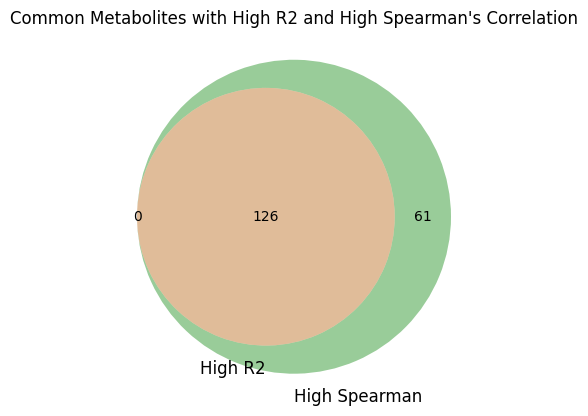

In [12]:
#Compare Spearman's top and R2 top

from matplotlib_venn import venn2

venn2([set(common_r2_high), set(common_spearman_high)], set_labels = ('High R2', 'High Spearman'))
plt.title("Common Metabolites with High R2 and High Spearman's Correlation")
plt.savefig(f'{path}/venn_common_r2_spearman.svg', bbox_inches = 'tight')
plt.show()

In [13]:
common_elements = set(common_r2_high).intersection(common_spearman_high)
with open(f'{path}/common_r2_spearman_high.txt', 'w') as file:
    for metabolite in common_elements:
        file.write(f"{metabolite}\n")

In [14]:
r2_data = pd.concat([
                     r2_ridge.set_index('Metabolite').rename(columns = {'R2 Score' : 'Ridge'}),
                     r2_lasso.set_index('Metabolite').rename(columns = {'R2 Score' : 'Lasso'}),
                     r2_elastic.set_index('Metabolite').rename(columns = {'R2 Score' : 'Elastic Net'}),
                     r2_rf.set_index('Metabolite').rename(columns = {'R2 Score' : 'Random Forest Regressor'}),
                     r2_xgb.set_index('Metabolite').rename(columns = {'R2 Score' : 'XGBoost Regressor'}),
                     r2_lgbm.set_index('Metabolite').rename(columns = {'R2 Score' : 'LighGBM Regressor'}),
                     r2_mlp.set_index('Metabolite').rename(columns = {'R2 Score' : 'MLP Regressor'}),
                     r2_ensemble.set_index('Metabolite').rename(columns = {'R2 Score' : 'Ensemble'})
                     ], axis = 'columns')
r2_data

,Ridge,Lasso,Elastic Net,Random Forest Regressor,XGBoost Regressor,LighGBM Regressor,MLP Regressor,Ensemble
Metabolite,,,,,,,,
tyrosine,0.884501,0.885481,0.886213,0.939818,0.845723,0.861155,0.890177,0.915483
stearoyl sphingomyelin (d18:1/18:0),0.835652,0.834272,0.835572,0.851888,0.894021,0.809987,0.815167,0.936145
hippurate,0.828087,0.828254,0.829232,0.803664,0.754554,0.747301,0.785636,0.888225
1-palmitoyl-GPE (16:0),0.822013,0.821961,0.822614,0.766930,0.791087,0.787388,0.782395,0.855311
isoleucine,0.807180,0.810051,0.810712,0.808494,0.799493,0.758457,0.840232,0.898147
...,...,...,...,...,...,...,...,...
N6-acetyllysine,0.075063,0.099170,0.083156,0.385782,0.335138,-0.039463,-0.000014,0.590459
alanylleucine,0.016924,0.021806,0.015360,0.017021,0.212944,-0.006186,-0.049459,-0.048384
lidocaine,0.015847,0.038261,0.022007,0.438330,0.346847,0.062172,0.167359,0.680743


/tmp/ipython-input-2358652055.py:7: UserWarning: 
The palette list has fewer values (6) than needed (218) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x="Model", y="R2", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette)


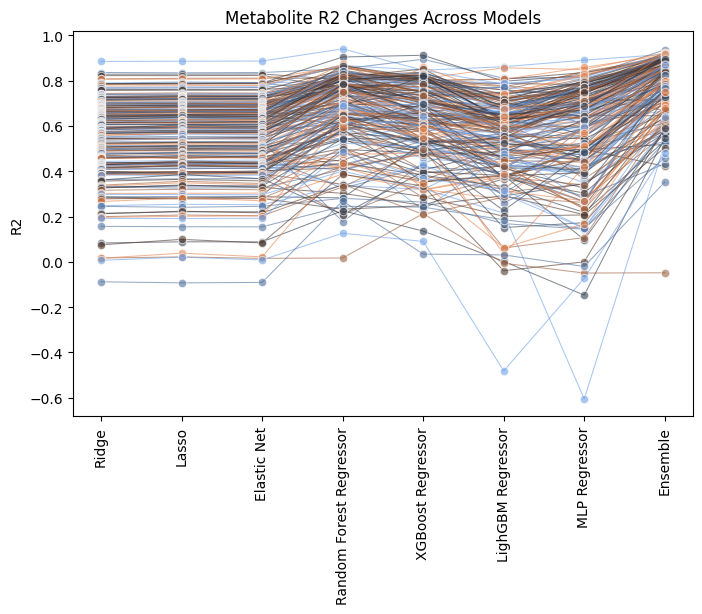

In [15]:
df_long = r2_data.reset_index().melt(id_vars="Metabolite", var_name="Model", value_name="R2")
df_long.rename(columns={"Metabolite": "Metabolite"}, inplace=True)

# Plot
plt.figure(figsize=(8, 5))
palette = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False)
sns.lineplot(x="Model", y="R2", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette)
plt.xticks(rotation = 90)
plt.title("Metabolite R2 Changes Across Models")
plt.xlabel('')
plt.savefig(f'{path}/R2_changes_across_models.svg', bbox_inches = 'tight')
plt.show()

In [16]:
spermans_data = pd.concat([
                            spearman_ridge.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'Ridge'}),
                            spearman_lasso.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'Lasso'}),
                            spearman_elastic.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'Elastic Net'}),
                            spearman_rf.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'Random Forest Regressor'}),
                            spearman_xgb.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'XGBoost Regressor'}),
                            spearman_lgbm.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'LighGBM Regressor'}),
                            spearman_mlp.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'MLP Regressor'}),
                            spearman_ensemble.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'Ensemble'})
                            ], axis = 'columns')
spermans_data

,Ridge,Lasso,Elastic Net,Random Forest Regressor,XGBoost Regressor,LighGBM Regressor,MLP Regressor,Ensemble
Metabolite,,,,,,,,
hippurate,0.891575,0.889268,0.891566,0.863734,0.801599,0.815658,0.866031,0.900450
creatinine,0.877603,0.871492,0.874081,0.897904,0.905938,0.844704,0.888039,0.907626
lactate,0.842229,0.836716,0.842088,0.913107,0.879073,0.816427,0.817924,0.885981
4-acetamidophenylglucuronide,0.840548,0.837177,0.840503,0.877156,0.839687,0.820491,0.841689,0.925348
phenylacetylglutamine,0.836603,0.843285,0.837381,0.881091,0.853991,0.811732,0.799429,0.892310
...,...,...,...,...,...,...,...,...
gamma-glutamylphenylalanine,0.366768,0.348048,0.361303,0.678615,0.540492,0.447900,0.273710,0.670631
erythritol,0.354282,0.366010,0.356845,0.630339,0.546385,0.400476,0.309776,0.671563
"1,5-anhydroglucitol (1,5-AG)",0.319920,0.315890,0.320309,0.571670,0.334303,0.293089,0.282944,0.626577


/tmp/ipython-input-4090828794.py:7: UserWarning: 
The palette list has fewer values (6) than needed (218) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x="Model", y="Spearman's Coefficient", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette)


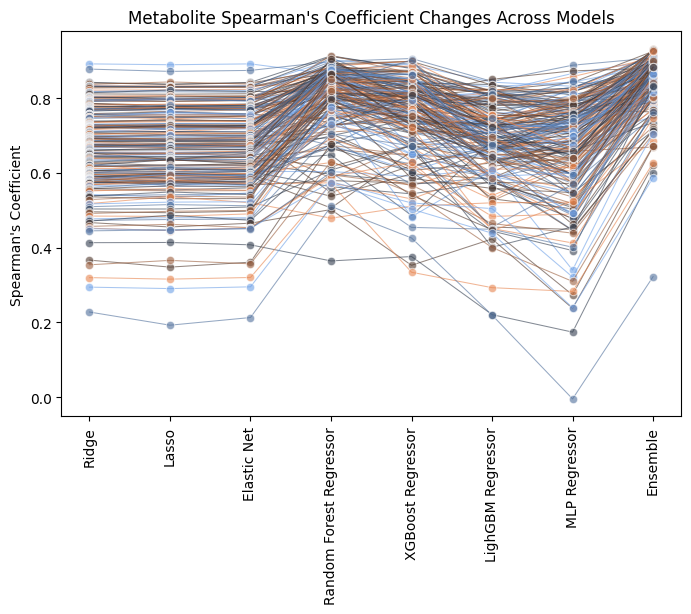

In [17]:
df_long = spermans_data.reset_index().melt(id_vars="Metabolite", var_name="Model", value_name="Spearman's Coefficient")
df_long.rename(columns={"Metabolite": "Metabolite"}, inplace=True)

# Plot
plt.figure(figsize=(8, 5))
palette = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False)
sns.lineplot(x="Model", y="Spearman's Coefficient", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette)
plt.xticks(rotation = 90)
plt.title("Metabolite Spearman's Coefficient Changes Across Models")
plt.xlabel('')
plt.savefig(f'{path}/Spearmans_changes_across_models.svg', bbox_inches = 'tight')
plt.show()